# VIC Return Forecasting: EGARCH + XGBoost/LightGBM

Notebook này gom toàn bộ pipeline nghiên cứu vào một file: tải dữ liệu VIC, tạo feature, sinh volatility feature từ EGARCH, train mô hình boosting, đánh giá và backtest đơn giản.

Target mặc định: `target_return_next_1d = log(P(t+1) / P(t))`.

## 1. Cấu Hình

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<p>Cell này tách toàn bộ giả định nghiên cứu vào một cấu hình duy nhất: mã cổ phiếu, khoảng thời gian, horizon dự báo, cửa sổ rolling, tỷ lệ train/validation/test và chi phí giao dịch. Cách làm này giúp thí nghiệm có tính tái lập, vì mọi thay đổi về thiết kế nghiên cứu đều được ghi nhận ở một nơi thay vì nằm rải rác trong code.</p>

</div>

In [19]:
from pathlib import Path

CONFIG = {
    "symbol": "VIC",
    "start": "2015-01-01",
    "end": None,  # None = tới ngày hiện tại theo nguồn dữ liệu
    "raw_csv": Path("data/raw/VIC.csv"),
    "processed_dir": Path("data/processed"),
    "model_dir": Path("models"),
    "report_dir": Path("reports"),
    "target_name": "target_return_next_1d",
    "horizon": 1,
    "return_lags": [1, 2, 3, 5, 10, 20],
    "rolling_windows": [5, 10, 20, 60],
    "rsi_windows": [14],
    "train_size": 0.70,
    "valid_size": 0.15,
    "test_size": 0.15,
    "random_state": 42,
    "use_egarch": True,
    "egarch_min_obs": 500,
    "egarch_max_train_window": 1000,
    "transaction_cost_bps": 15,
}

for key in ["processed_dir", "model_dir", "report_dir", "raw_csv"]:
    path = CONFIG[key]
    if path.suffix:
        path.parent.mkdir(parents=True, exist_ok=True)
    else:
        path.mkdir(parents=True, exist_ok=True)

CONFIG

{'symbol': 'VIC',
 'start': '2015-01-01',
 'end': None,
 'raw_csv': PosixPath('data/raw/VIC.csv'),
 'processed_dir': PosixPath('data/processed'),
 'model_dir': PosixPath('models'),
 'report_dir': PosixPath('reports'),
 'target_name': 'target_return_next_1d',
 'horizon': 1,
 'return_lags': [1, 2, 3, 5, 10, 20],
 'rolling_windows': [5, 10, 20, 60],
 'rsi_windows': [14],
 'train_size': 0.7,
 'valid_size': 0.15,
 'test_size': 0.15,
 'random_state': 42,
 'use_egarch': True,
 'egarch_min_obs': 500,
 'egarch_max_train_window': 1000,
 'transaction_cost_bps': 15}

## 2. Import Thư Viện

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<h4 style="margin-top:0">Nhận xét học thuật - Hệ thư viện</h4>
<p>Cell import được thiết kế theo hướng <i>graceful degradation</i>: nếu thiếu <code>arch</code>, <code>xgboost</code> hoặc <code>lightgbm</code>, notebook vẫn có thể chạy các phần còn lại. Điều này phù hợp với workflow nghiên cứu thực nghiệm, nơi ta thường chạy từng phần: khám phá dữ liệu trước, sau đó mới cài đầy đủ mô hình.</p>

</div>

In [20]:
import json
import pickle
import warnings
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")

try:
    import lightgbm as lgb
except ImportError:
    lgb = None

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

try:
    from arch import arch_model
except ImportError:
    arch_model = None

print("lightgbm:", lgb is not None)
print("xgboost:", XGBRegressor is not None)
print("arch:", arch_model is not None)

lightgbm: True
xgboost: True
arch: True


## 3. Tải Dữ Liệu VIC

Nếu `data/raw/VIC.csv` đã có sẵn, cell này sẽ đọc file đó. Nếu chưa có, notebook thử tải bằng `vnstock`.

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<h4 style="margin-top:0">Nhận xét học thuật - Thu thập dữ liệu</h4>
<p>Dữ liệu OHLCV được lấy từ nguồn chuyên cho thị trường Việt Nam và lưu về CSV cục bộ. Việc cache dữ liệu thô tại <code>data/raw/VIC.csv</code> rất quan trọng: nó giúp các lần chạy sau dùng cùng một snapshot dữ liệu, tránh việc kết quả thay đổi chỉ vì nguồn online cập nhật hoặc điều chỉnh dữ liệu lịch sử.</p>

</div>

In [21]:
def download_vic_with_vnstock(symbol="VIC", start="2015-01-01", end=None, output=Path("data/raw/VIC.csv")):
    from vnstock.api.quote import Quote

    end = end or date.today().isoformat()
    errors = []
    for source in ["VCI", "KBS"]:
        try:
            q = Quote(symbol=symbol, source=source, show_log=False)
            df = q.history(symbol=symbol, start=start, end=end, interval="1D")
            if df is None or df.empty:
                errors.append(f"{source}: empty")
                continue
            df = df.copy()
            df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]
            rename = {"time": "date", "datetime": "date", "vol": "volume"}
            df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})
            required = ["date", "open", "high", "low", "close", "volume"]
            missing = [c for c in required if c not in df.columns]
            if missing:
                errors.append(f"{source}: missing {missing}; columns={list(df.columns)}")
                continue
            df = df[required]
            df["date"] = pd.to_datetime(df["date"]).dt.date.astype(str)
            df = df[(df["date"] >= start) & (df["date"] <= end)]
            df = df.sort_values("date").drop_duplicates("date")
            output.parent.mkdir(parents=True, exist_ok=True)
            df.to_csv(output, index=False)
            print(f"Saved {len(df)} rows from vnstock/{source} to {output}")
            return df
        except Exception as exc:
            errors.append(f"{source}: {exc}")
    raise RuntimeError("Cannot download VIC with vnstock. " + " | ".join(errors))

if CONFIG["raw_csv"].exists():
    raw = pd.read_csv(CONFIG["raw_csv"])
    print(f"Loaded existing file: {CONFIG['raw_csv']} | rows={len(raw)}")
else:
    raw = download_vic_with_vnstock(
        symbol=CONFIG["symbol"],
        start=CONFIG["start"],
        end=CONFIG["end"],
        output=CONFIG["raw_csv"],
    )

raw.head(), raw.tail()

Loaded existing file: data/raw/VIC.csv | rows=2872


(         date   open   high    low  close  volume
 0  2015-01-05  10.24  10.24  10.16  10.22  320790
 1  2015-01-06  10.18  10.26  10.16  10.26  462360
 2  2015-01-07  10.26  10.31  10.20  10.24  319600
 3  2015-01-08  10.24  10.39  10.24  10.31  788420
 4  2015-01-09  10.31  10.43  10.26  10.26  969330,
             date   open   high    low  close   volume
 2867  2026-07-01  220.0  220.2  216.7  217.1  1760600
 2868  2026-07-02  217.1  221.2  216.1  220.3  2543800
 2869  2026-07-03  219.9  222.9  219.3  220.3  2086300
 2870  2026-07-06  222.5  222.7  217.1  220.3  3093000
 2871  2026-07-07  218.5  220.3  215.2  220.3  2948800)

## 4. Làm Sạch Dữ Liệu Và Tạo Target

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<h4 style="margin-top:0">Nhận xét học thuật - Làm sạch dữ liệu và định nghĩa target</h4>
<p>Cell này chuẩn hóa tên cột, ép kiểu số, sắp xếp theo thời gian và tạo log-return. Log-return được dùng vì có tính cộng dồn theo thời gian và thường phù hợp hơn simple return trong mô hình tài chính. Target <code>log(P(t+1)/P(t))</code> bảo đảm dự báo là out-of-sample theo thời gian: tại ngày <code>t</code>, mô hình chỉ dùng thông tin đến ngày <code>t</code> để dự báo ngày <code>t+1</code>.</p>

</div>

In [22]:
def load_ohlcv(path):
    df = pd.read_csv(path)
    df.columns = [str(c).strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]
    if "datetime" in df.columns and "date" not in df.columns:
        df = df.rename(columns={"datetime": "date"})
    if "time" in df.columns and "date" not in df.columns:
        df = df.rename(columns={"time": "date"})
    required = {"date", "open", "high", "low", "close", "volume"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")
    df["date"] = pd.to_datetime(df["date"])
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    price_col = "adj_close" if "adj_close" in df.columns else "close"
    df["price"] = pd.to_numeric(df[price_col], errors="coerce")
    df = df.sort_values("date").drop_duplicates("date")
    return df.dropna(subset=["date", "open", "high", "low", "close", "volume", "price"]).reset_index(drop=True)

df = load_ohlcv(CONFIG["raw_csv"])
df["log_price"] = np.log(df["price"])
df["return_1d"] = df["log_price"].diff()
df[CONFIG["target_name"]] = df["log_price"].shift(-CONFIG["horizon"]) - df["log_price"]
df["direction_next_1d"] = (df[CONFIG["target_name"]] > 0).astype("Int64")

print(df[["date", "open", "high", "low", "close", "volume", "return_1d", CONFIG["target_name"]]].head())
print(df[["date", "close", CONFIG["target_name"]]].tail())

        date   open   high    low  close  volume  return_1d  target_return_next_1d
0 2015-01-05  10.24  10.24  10.16  10.22  320790        NaN               0.003906
1 2015-01-06  10.18  10.26  10.16  10.26  462360   0.003906              -0.001951
2 2015-01-07  10.26  10.31  10.20  10.24  319600  -0.001951               0.006813
3 2015-01-08  10.24  10.39  10.24  10.31  788420   0.006813              -0.004861
4 2015-01-09  10.31  10.43  10.26  10.26  969330  -0.004861              -0.009794
           date  close  target_return_next_1d
2867 2026-07-01  217.1               0.014632
2868 2026-07-02  220.3               0.000000
2869 2026-07-03  220.3               0.000000
2870 2026-07-06  220.3               0.000000
2871 2026-07-07  220.3                    NaN


## 5. Feature Engineering

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<h4 style="margin-top:0">Feature engineering</h4>

<p><b>Mục tiêu:</b> Biến chuỗi giá OHLCV thành các biến giải thích có cơ sở tài chính hành vi, phân tích kỹ thuật và kinh tế lượng. Vì return cổ phiếu thường nhiễu và có autocorrelation yếu, nhóm feature được thiết kế để mô hình cây học được quan hệ phi tuyến giữa momentum, mean reversion, thanh khoản và volatility.</p>
<table style="border-collapse:collapse; width:100%; font-size:14px;">
<tr><th style="border:1px solid #d8dee9; padding:6px; background:#eef3fb; text-align:left;">Feature</th><th style="border:1px solid #d8dee9; padding:6px; background:#eef3fb; text-align:left;">Cách hiểu</th><th style="border:1px solid #d8dee9; padding:6px; background:#eef3fb; text-align:left;">Lý do đưa vào mô hình</th></tr>
<tr><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;"><code>return_lag_1,2,3,5,10,20</code></td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Return quá khứ theo nhiều độ trễ.</td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Kiểm tra momentum ngắn hạn và mean reversion. Với cổ phiếu thanh khoản cao, thông tin có thể phản ánh dần vào giá thay vì ngay lập tức.</td></tr>
<tr><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;"><code>return_mean_5,10,20,60</code></td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Return trung bình động.</td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Tóm tắt xu hướng lợi suất theo tuần, nửa tháng, tháng và quý giao dịch; giúp giảm nhiễu của từng phiên riêng lẻ.</td></tr>
<tr><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;"><code>return_vol_5,10,20,60</code></td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Độ lệch chuẩn rolling của return.</td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Đo rủi ro thay đổi theo thời gian. Return kỳ vọng có thể phụ thuộc vào regime volatility, đặc biệt trong thị trường mới nổi.</td></tr>
<tr><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;"><code>price_ma_5,10,20,60</code></td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Moving average của giá.</td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Đại diện xu hướng kỹ thuật. Mô hình cây dùng nó để nhận biết vùng giá so với lịch sử gần.</td></tr>
<tr><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;"><code>price_to_ma_5,10,20,60</code></td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Khoảng cách tương đối giữa giá và MA.</td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Đo trạng thái quá mua/quá bán hoặc breakout. Đây là dạng chuẩn hóa nên ổn định hơn giá tuyệt đối.</td></tr>
<tr><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;"><code>volume_mean_5,10,20,60</code></td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Thanh khoản trung bình động.</td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Volume cao/thấp kéo dài thường gắn với mức chú ý của nhà đầu tư và khả năng hấp thụ thông tin.</td></tr>
<tr><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;"><code>volume_to_mean_5,10,20,60</code></td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Volume hiện tại so với volume trung bình.</td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Bắt shock thanh khoản. Một biến volume chuẩn hóa giúp so sánh các giai đoạn có mức thanh khoản nền khác nhau.</td></tr>
<tr><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;"><code>hl_range</code></td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Log(high/low) trong ngày.</td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Đại diện biến động nội phiên; hữu ích khi close-to-close return bỏ qua dao động trong ngày.</td></tr>
<tr><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;"><code>oc_return</code></td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Log(close/open).</td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Đo áp lực mua/bán trong phiên giao dịch, khác với return qua đêm.</td></tr>
<tr><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;"><code>close_to_high</code>, <code>close_to_low</code></td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Vị trí giá đóng cửa so với biên ngày.</td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Nếu đóng gần high/low, phiên đó thể hiện lực cầu/cung cuối phiên; có thể liên quan đến return ngày sau.</td></tr>
<tr><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;"><code>macd</code>, <code>macd_signal</code>, <code>macd_hist</code></td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Chênh lệch EMA 12/26 và đường tín hiệu EMA 9.</td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Bắt xu hướng và gia tốc xu hướng; phù hợp với mô hình phi tuyến vì tác động MACD thường phụ thuộc regime.</td></tr>
<tr><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;"><code>atr_14</code></td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Average True Range 14 ngày.</td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Đo volatility bằng biên dao động giá, bổ sung cho rolling std của return.</td></tr>
<tr><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;"><code>rsi_14</code></td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Relative Strength Index.</td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Đo cường độ tăng/giảm gần đây; dùng để kiểm tra tín hiệu quá mua/quá bán.</td></tr>
<tr><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;"><code>day_of_week</code>, <code>month</code>, <code>is_month_end</code></td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Hiệu ứng lịch.</td><td style="border:1px solid #d8dee9; padding:6px; vertical-align:top;">Kiểm tra seasonality vi mô như hiệu ứng thứ trong tuần, cuối tháng, tái cơ cấu danh mục hoặc dòng tiền định kỳ.</td></tr>
</table>

</div>

In [23]:
def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

def rsi(price, window):
    delta = price.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def atr(data, window):
    prev_close = data["close"].shift(1)
    tr = pd.concat([
        data["high"] - data["low"],
        (data["high"] - prev_close).abs(),
        (data["low"] - prev_close).abs(),
    ], axis=1).max(axis=1)
    return tr.rolling(window).mean()

def add_features(data):
    out = data.copy()
    for lag in CONFIG["return_lags"]:
        out[f"return_lag_{lag}"] = out["return_1d"].shift(lag)
    for window in CONFIG["rolling_windows"]:
        out[f"return_mean_{window}"] = out["return_1d"].rolling(window).mean()
        out[f"return_vol_{window}"] = out["return_1d"].rolling(window).std()
        out[f"price_ma_{window}"] = out["price"].rolling(window).mean()
        out[f"price_to_ma_{window}"] = out["price"] / out[f"price_ma_{window}"] - 1
        out[f"volume_mean_{window}"] = out["volume"].rolling(window).mean()
        out[f"volume_to_mean_{window}"] = out["volume"] / out[f"volume_mean_{window}"] - 1
    out["hl_range"] = np.log(out["high"] / out["low"])
    out["oc_return"] = np.log(out["close"] / out["open"])
    out["close_to_high"] = out["close"] / out["high"] - 1
    out["close_to_low"] = out["close"] / out["low"] - 1
    out["macd"] = ema(out["price"], 12) - ema(out["price"], 26)
    out["macd_signal"] = ema(out["macd"], 9)
    out["macd_hist"] = out["macd"] - out["macd_signal"]
    out["atr_14"] = atr(out, 14)
    for window in CONFIG["rsi_windows"]:
        out[f"rsi_{window}"] = rsi(out["price"], window)
    out["day_of_week"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month
    out["is_month_end"] = out["date"].dt.is_month_end.astype(int)
    return out

df = add_features(df)
df.filter(regex="return_lag|return_vol|rsi|macd|atr").head()

,return_lag_1,return_lag_2,return_lag_3,return_lag_5,return_lag_10,return_lag_20,return_vol_5,return_vol_10,return_vol_20,return_vol_60,macd,macd_signal,macd_hist,atr_14,rsi_14
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003191,0.000638,0.002553,NaN,NaN
2,0.003906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004059,0.001322,0.002737,NaN,NaN
3,-0.001951,0.003906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010277,0.003113,0.007164,NaN,NaN
4,0.006813,-0.001951,0.003906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011043,0.004699,0.006344,NaN,NaN


## 6. EGARCH Features

Cell này dùng walk-forward EGARCH để hạn chế leakage. Nếu chưa cài `arch`, notebook tự bỏ qua EGARCH và vẫn train được model boosting.

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<p>EGARCH được dùng để mô hình hóa volatility bất đối xứng: tin xấu thường làm biến động tăng mạnh hơn tin tốt. Cách fit <i>walk-forward</i> giúp tránh look-ahead bias vì volatility tại thời điểm hiện tại chỉ được ước lượng từ dữ liệu quá khứ. Các feature như <code>egarch_cond_vol</code>, <code>egarch_std_resid</code>, <code>egarch_forecast_vol_1d</code> đưa tri thức kinh tế lượng vào mô hình boosting, tạo dạng hybrid model thay vì ML thuần túy.</p>

</div>

In [24]:
def add_walk_forward_egarch_features(data, min_obs=500, max_train_window=1000):
    if arch_model is None:
        print("Package 'arch' chưa được cài, bỏ qua EGARCH features.")
        return data

    out = data.copy()
    returns_pct = out["return_1d"] * 100
    out["egarch_cond_vol"] = np.nan
    out["egarch_std_resid"] = np.nan
    out["egarch_forecast_vol_1d"] = np.nan

    valid_positions = np.flatnonzero(returns_pct.notna().to_numpy())
    if len(valid_positions) < min_obs:
        print(f"Không đủ dữ liệu cho EGARCH: {len(valid_positions)} < {min_obs}. Bỏ qua EGARCH.")
        return out

    for count, pos in enumerate(valid_positions):
        if count + 1 < min_obs:
            continue
        start_count = max(0, count + 1 - max_train_window) if max_train_window else 0
        train_positions = valid_positions[start_count: count + 1]
        train_returns = returns_pct.iloc[train_positions].dropna()
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model = arch_model(train_returns, mean="Constant", vol="EGARCH", p=1, o=1, q=1, dist="normal")
                result = model.fit(disp="off", show_warning=False)
                forecast = result.forecast(horizon=1, reindex=False)
            out.iloc[pos, out.columns.get_loc("egarch_cond_vol")] = result.conditional_volatility.iloc[-1] / 100
            out.iloc[pos, out.columns.get_loc("egarch_std_resid")] = result.std_resid.iloc[-1]
            out.iloc[pos, out.columns.get_loc("egarch_forecast_vol_1d")] = np.sqrt(forecast.variance.iloc[-1, 0]) / 100
        except Exception:
            continue

    out["egarch_abs_std_resid"] = out["egarch_std_resid"].abs()
    out["egarch_negative_shock"] = np.minimum(out["egarch_std_resid"], 0)
    return out

if CONFIG["use_egarch"]:
    df = add_walk_forward_egarch_features(
        df,
        min_obs=CONFIG["egarch_min_obs"],
        max_train_window=CONFIG["egarch_max_train_window"],
    )

df.filter(regex="egarch").tail()

,egarch_cond_vol,egarch_std_resid,egarch_forecast_vol_1d,egarch_abs_std_resid,egarch_negative_shock
2867,0.033447,-3.967316e-01,0.030979,3.967316e-01,-3.967316e-01
2868,0.030975,4.723908e-01,0.030181,4.723908e-01,0.000000e+00
2869,0.030148,3.290853e-09,0.026909,3.290853e-09,0.000000e+00
2870,0.026786,-2.022629e-08,0.023974,2.022629e-08,-2.022629e-08
2871,0.023864,3.025360e-09,0.021440,3.025360e-09,0.000000e+00


## 7. Tạo Dataset Và Chia Train/Validation/Test

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<p>Cell này loại bỏ các cột không nên đưa trực tiếp vào mô hình như ngày, giá thô và target, sau đó chia dữ liệu theo thứ tự thời gian. Không dùng random split vì dữ liệu tài chính có phụ thuộc chuỗi thời gian; random split sẽ làm rò rỉ thông tin tương lai vào tập train và khiến kết quả quá lạc quan.</p>

</div>

In [25]:
excluded = {
    "date", "open", "high", "low", "close", "adj_close", "volume", "price",
    "log_price", CONFIG["target_name"], "direction_next_1d",
}
feature_cols = [
    col for col in df.columns
    if col not in excluded and pd.api.types.is_numeric_dtype(df[col])
]

model_df = df[["date", CONFIG["target_name"], "direction_next_1d", *feature_cols]].replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna(subset=[CONFIG["target_name"], *feature_cols]).reset_index(drop=True)

n = len(model_df)
train_end = int(n * CONFIG["train_size"])
valid_end = train_end + int(n * CONFIG["valid_size"])
train_df = model_df.iloc[:train_end].copy()
valid_df = model_df.iloc[train_end:valid_end].copy()
test_df = model_df.iloc[valid_end:].copy()

CONFIG["processed_dir"].mkdir(parents=True, exist_ok=True)
model_df.to_csv(CONFIG["processed_dir"] / "features_notebook.csv", index=False)

print("rows:", len(model_df), "features:", len(feature_cols))
print("train:", train_df.date.min().date(), "->", train_df.date.max().date(), len(train_df))
print("valid:", valid_df.date.min().date(), "->", valid_df.date.max().date(), len(valid_df))
print("test :", test_df.date.min().date(), "->", test_df.date.max().date(), len(test_df))

rows: 2369 features: 48
train: 2017-01-04 -> 2023-08-24 1658
valid: 2023-08-25 -> 2025-01-23 355
test : 2025-01-24 -> 2026-07-06 356


## 8. Train LightGBM Và XGBoost

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<p>LightGBM và XGBoost là các mô hình gradient boosting trên cây quyết định, phù hợp với dữ liệu dạng bảng và quan hệ phi tuyến giữa technical indicators, volatility và return. Validation set được giữ riêng để theo dõi khả năng tổng quát hóa trước khi đánh giá cuối cùng trên test set.</p>

</div>

In [26]:
models = {}

if lgb is not None:
    train_data = lgb.Dataset(train_df[feature_cols], label=train_df[CONFIG["target_name"]], feature_name=feature_cols)
    valid_data = lgb.Dataset(valid_df[feature_cols], label=valid_df[CONFIG["target_name"]], feature_name=feature_cols, reference=train_data)
    lgb_params = {
        "objective": "regression",
        "metric": "rmse",
        "learning_rate": 0.03,
        "num_leaves": 31,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "seed": CONFIG["random_state"],
        "verbosity": -1,
    }
    models["lightgbm"] = lgb.train(lgb_params, train_data, num_boost_round=500, valid_sets=[valid_data], valid_names=["valid"])
else:
    print("LightGBM chưa được cài.")

if XGBRegressor is not None:
    xgb = XGBRegressor(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=CONFIG["random_state"],
        n_jobs=-1,
    )
    xgb.fit(train_df[feature_cols], train_df[CONFIG["target_name"]], eval_set=[(valid_df[feature_cols], valid_df[CONFIG["target_name"]])], verbose=False)
    models["xgboost"] = xgb
else:
    print("XGBoost chưa được cài.")

if not models:
    raise RuntimeError("Chưa có LightGBM hoặc XGBoost. Hãy cài: pip install lightgbm xgboost")

print("trained models:", list(models))

trained models: ['lightgbm', 'xgboost']


## 9. Đánh Giá Và Backtest

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<p>Đánh giá gồm hai lớp: thống kê dự báo và ý nghĩa giao dịch. RMSE/MAE đo sai số định lượng của return, directional accuracy/F1 đo khả năng dự báo chiều tăng giảm, còn backtest long-flat kiểm tra liệu tín hiệu có tạo giá trị kinh tế sau chi phí giao dịch hay không. Đây là cách trình bày cân bằng giữa machine learning và tài chính thực nghiệm.</p>

</div>

In [27]:
def predict_model(model, data):
    return model.predict(data[feature_cols])

def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = actual - predicted
    rmse = float(np.sqrt(np.mean(error ** 2)))
    mae = float(np.mean(np.abs(error)))
    denom = np.sum((actual - actual.mean()) ** 2)
    r2 = float(1 - np.sum(error ** 2) / denom) if denom != 0 else 0.0
    actual_dir = actual > 0
    pred_dir = predicted > 0
    directional_accuracy = float(np.mean(actual_dir == pred_dir))
    tp = np.sum(actual_dir & pred_dir)
    fp = np.sum(~actual_dir & pred_dir)
    fn = np.sum(actual_dir & ~pred_dir)
    f1 = float(2 * tp / (2 * tp + fp + fn)) if (2 * tp + fp + fn) else 0.0
    return {"rmse": rmse, "mae": mae, "r2": r2, "directional_accuracy": directional_accuracy, "f1_direction": f1}

def backtest_long_flat(pred_df, transaction_cost_bps=15):
    out = pred_df.sort_values("date").copy()
    out["position"] = (out["predicted_return"] > 0).astype(float)
    out["trade"] = out["position"].diff().abs().fillna(out["position"].abs())
    out["cost"] = out["trade"] * transaction_cost_bps / 10000
    out["strategy_return"] = out["position"] * out["actual_return"] - out["cost"]
    out["buy_hold_return"] = out["actual_return"]
    out["strategy_equity"] = np.exp(out["strategy_return"].cumsum())
    out["buy_hold_equity"] = np.exp(out["buy_hold_return"].cumsum())
    return out

def annualized_sharpe(returns, periods_per_year=252):
    std = returns.std()
    if std == 0 or np.isnan(std):
        return 0.0
    return float(np.sqrt(periods_per_year) * returns.mean() / std)

def max_drawdown(equity):
    return float((equity / equity.cummax() - 1).min())

predictions = []
metrics = {}
backtest_metrics = {}

for name, model in models.items():
    pred = predict_model(model, test_df)
    pred_df = pd.DataFrame({
        "date": test_df["date"].to_numpy(),
        "model": name,
        "actual_return": test_df[CONFIG["target_name"]].to_numpy(),
        "predicted_return": pred,
        "actual_direction": (test_df[CONFIG["target_name"]].to_numpy() > 0).astype(int),
        "predicted_direction": (pred > 0).astype(int),
    })
    predictions.append(pred_df)
    metrics[name] = regression_metrics(pred_df["actual_return"], pred_df["predicted_return"])

    bt = backtest_long_flat(pred_df, transaction_cost_bps=CONFIG["transaction_cost_bps"])
    bt.to_csv(CONFIG["report_dir"] / f"backtest_{name}_notebook.csv", index=False)
    backtest_metrics[name] = {
        "strategy_total_return": float(bt["strategy_equity"].iloc[-1] - 1),
        "buy_hold_total_return": float(bt["buy_hold_equity"].iloc[-1] - 1),
        "strategy_sharpe": annualized_sharpe(bt["strategy_return"]),
        "strategy_max_drawdown": max_drawdown(bt["strategy_equity"]),
    }

predictions_df = pd.concat(predictions, ignore_index=True)
predictions_df.to_csv(CONFIG["report_dir"] / "predictions_notebook.csv", index=False)

summary = {"test_metrics": metrics, "backtest": backtest_metrics, "n_rows": len(model_df), "n_features": len(feature_cols)}
with open(CONFIG["report_dir"] / "metrics_notebook.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

pd.DataFrame(metrics).T

,rmse,mae,r2,directional_accuracy,f1_direction
lightgbm,0.034130,0.025819,-0.078571,0.522472,0.589372
xgboost,0.036846,0.028439,-0.257096,0.497191,0.442368


## 10. Lưu Model Và Feature Importance

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<p>Cell này lưu mô hình cùng danh sách feature để bảo đảm inference sau này dùng đúng thứ tự biến. Feature importance không chứng minh quan hệ nhân quả, nhưng là công cụ diễn giải hữu ích để xem mô hình đang dựa nhiều vào nhóm thông tin nào: momentum, volatility, thanh khoản, kỹ thuật hay EGARCH.</p>

</div>

In [28]:
for name, model in models.items():
    with open(CONFIG["model_dir"] / f"{name}_notebook.pkl", "wb") as f:
        pickle.dump({"model": model, "feature_cols": feature_cols, "target_name": CONFIG["target_name"]}, f)

    if hasattr(model, "feature_importance"):
        importance = model.feature_importance(importance_type="gain")
    elif hasattr(model, "feature_importances_"):
        importance = model.feature_importances_
    else:
        importance = np.zeros(len(feature_cols))

    imp = pd.DataFrame({"feature": feature_cols, "importance": importance}).sort_values("importance", ascending=False)
    imp.to_csv(CONFIG["report_dir"] / f"feature_importance_{name}_notebook.csv", index=False)
    display(imp.head(20))

print("Saved outputs to:", CONFIG["report_dir"], CONFIG["model_dir"])

,feature,importance
45,egarch_forecast_vol_1d,0.335537
5,return_lag_10,0.335030
43,egarch_cond_vol,0.316446
38,atr_14,0.313590
14,return_vol_10,0.305723
31,hl_range,0.298090
35,macd,0.282332
22,price_to_ma_20,0.280853
2,return_lag_2,0.273299
46,egarch_abs_std_resid,0.268157


,feature,importance
38,atr_14,0.029346
47,egarch_negative_shock,0.027977
27,price_ma_60,0.027802
10,price_to_ma_5,0.026816
19,return_mean_20,0.026593
36,macd_signal,0.025653
28,price_to_ma_60,0.025375
20,return_vol_20,0.024013
4,return_lag_5,0.023858
46,egarch_abs_std_resid,0.023672


Saved outputs to: reports models


## 11. Dự Báo Dòng Mới Nhất

Dòng cuối thường chưa có actual return của ngày kế tiếp, nhưng vẫn có thể tạo dự báo `predicted_return`.

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<p>Dòng cuối của dữ liệu thường chưa có actual return ngày kế tiếp, nhưng vẫn có đủ feature tại thời điểm hiện tại để tạo forecast. Đây là khác biệt giữa đánh giá lịch sử và ứng dụng thực tế: trong thực tế, ta quan tâm tín hiệu dự báo trước khi outcome được quan sát.</p>

</div>

In [29]:
latest_rows = df[["date", *feature_cols, CONFIG["target_name"]]].replace([np.inf, -np.inf], np.nan)
latest_rows = latest_rows.dropna(subset=feature_cols).reset_index(drop=True)

latest_predictions = []
for name, model in models.items():
    pred = predict_model(model, latest_rows)
    tmp = pd.DataFrame({
        "date": latest_rows["date"],
        "model": name,
        "predicted_return": pred,
        "predicted_direction": (pred > 0).astype(int),
        "actual_return": latest_rows[CONFIG["target_name"]],
    })
    latest_predictions.append(tmp.tail(5))

latest_predictions = pd.concat(latest_predictions, ignore_index=True)
latest_predictions.to_csv(CONFIG["report_dir"] / "latest_predictions_notebook.csv", index=False)
latest_predictions

,date,model,predicted_return,predicted_direction,actual_return
0,2026-07-01,lightgbm,0.006055,1,0.014632
1,2026-07-02,lightgbm,-0.014031,0,0.000000
2,2026-07-03,lightgbm,-0.005008,0,0.000000
3,2026-07-06,lightgbm,-0.002627,0,0.000000
4,2026-07-07,lightgbm,0.001017,1,NaN
5,2026-07-01,xgboost,-0.014196,0,0.014632
6,2026-07-02,xgboost,-0.016560,0,0.000000
7,2026-07-03,xgboost,-0.010071,0,0.000000
8,2026-07-06,xgboost,-0.007776,0,0.000000
9,2026-07-07,xgboost,-0.009278,0,NaN


## 12. Trực Quan Hóa Kết Quả

Các biểu đồ dưới đây phục vụ phần phân tích thực nghiệm: diễn biến giá, phân phối return, volatility, khả năng dự báo, backtest và feature importance.

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<p>Các biểu đồ cơ bản giúp kiểm tra tính hợp lý của dữ liệu và mô hình: giá/volume cho bối cảnh thị trường, histogram return cho phân phối đuôi dày, rolling volatility cho volatility clustering, actual-vs-predicted cho chất lượng dự báo, equity curve cho ý nghĩa kinh tế và feature importance cho diễn giải mô hình.</p>

</div>

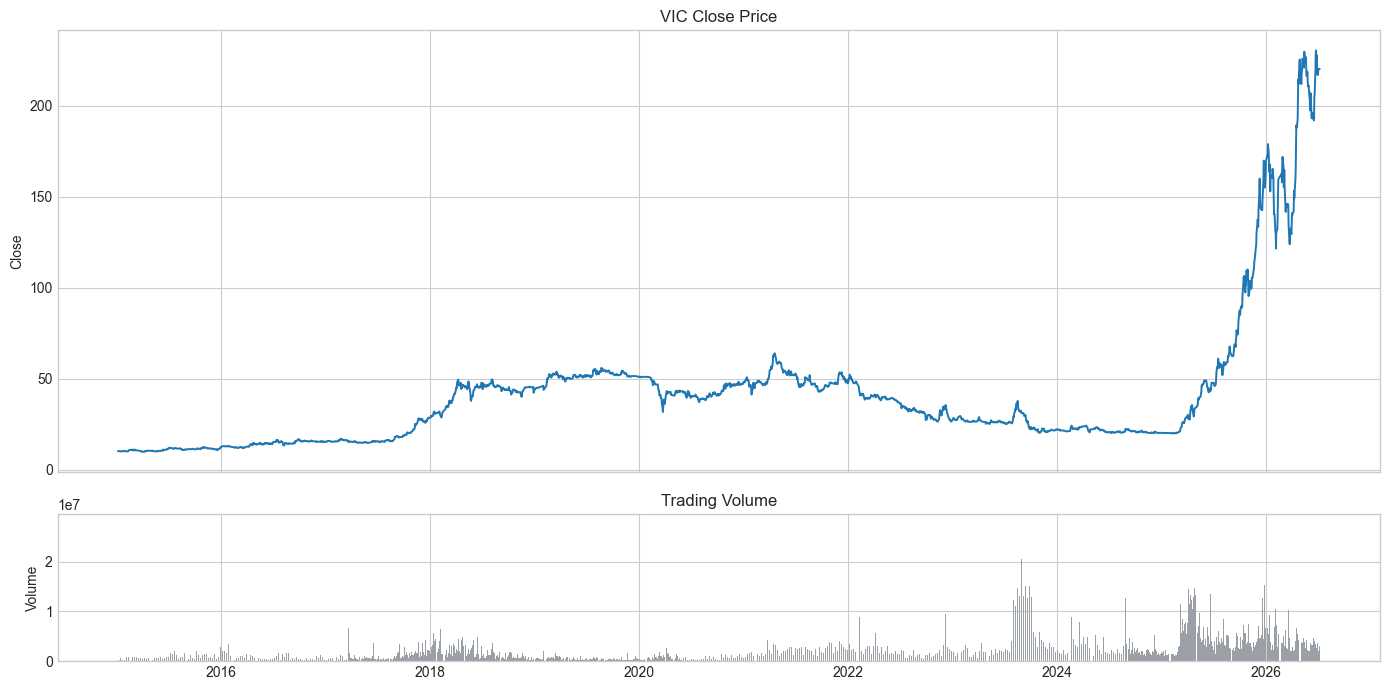

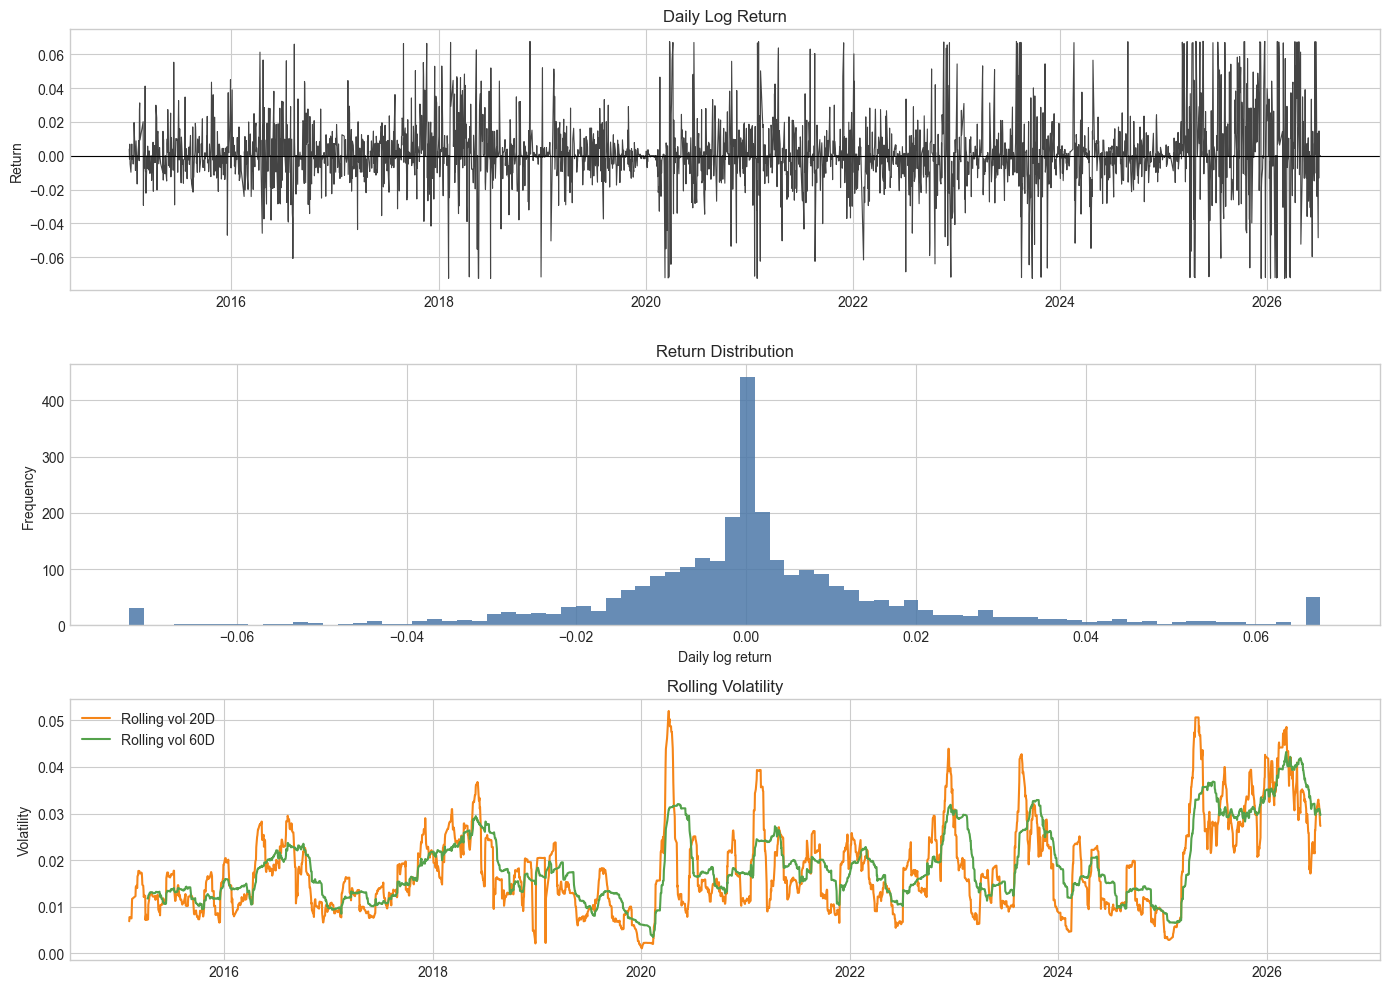

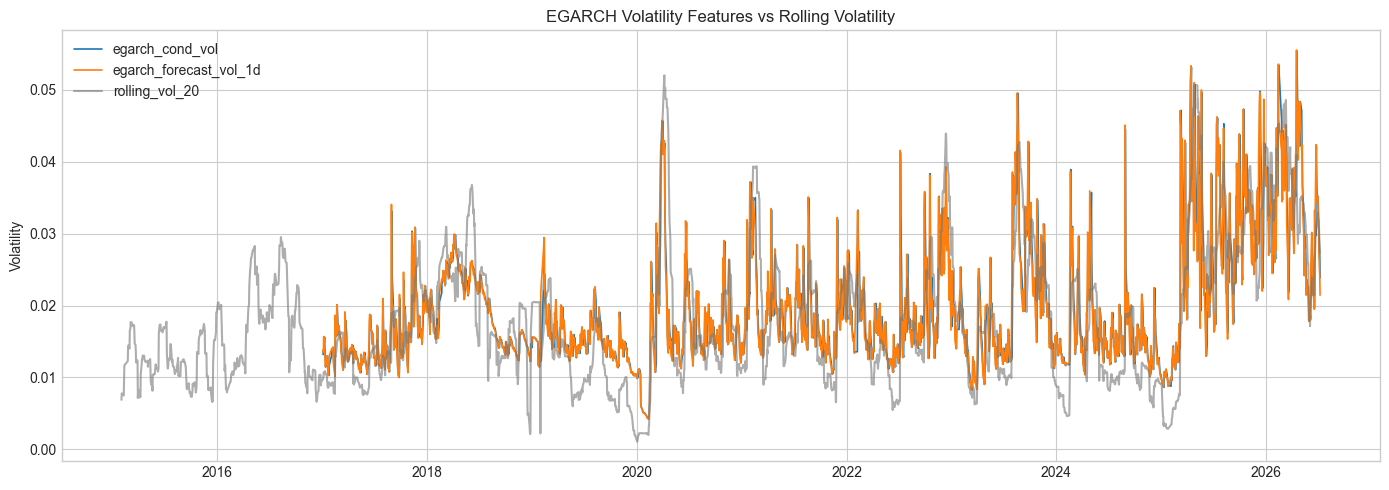

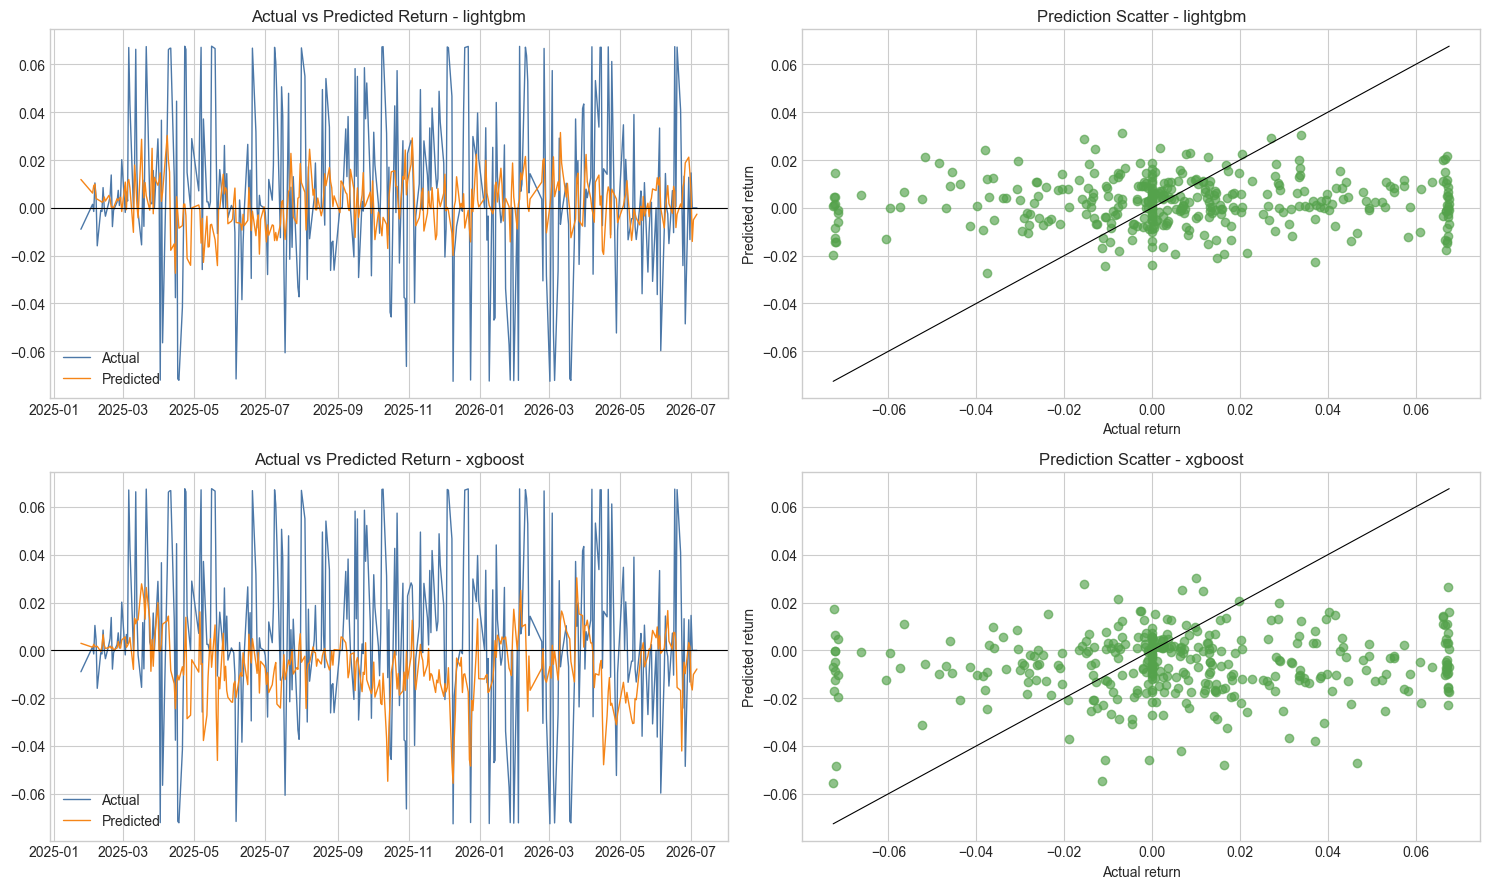

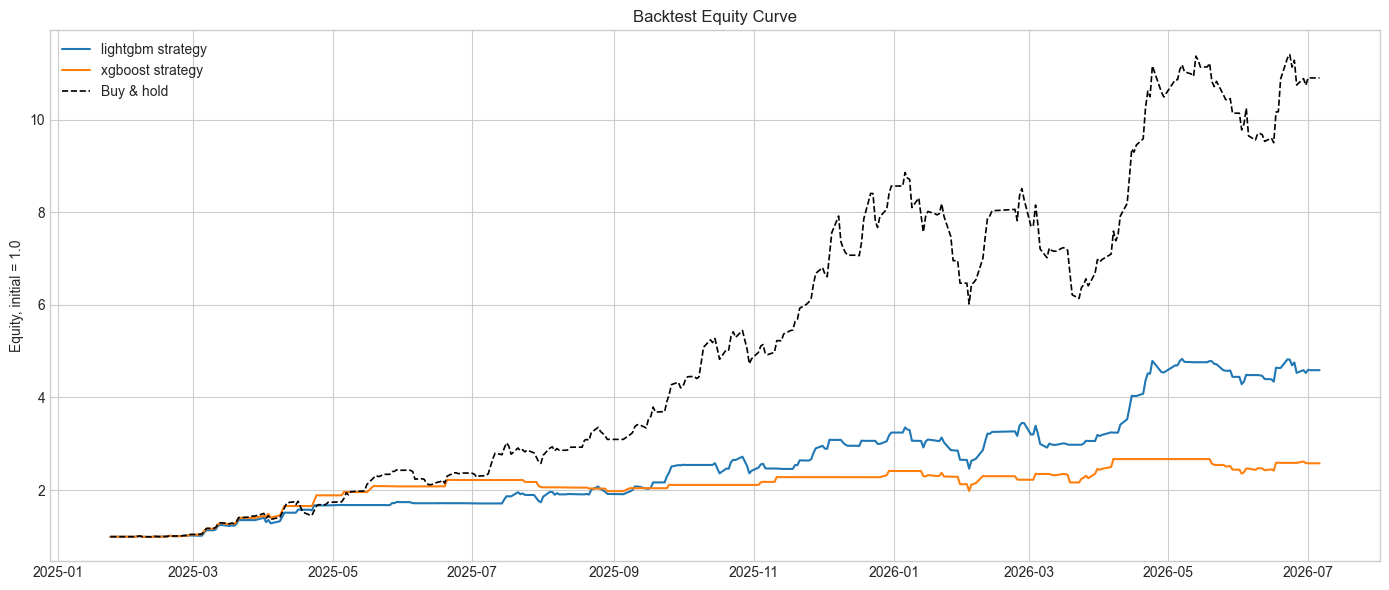

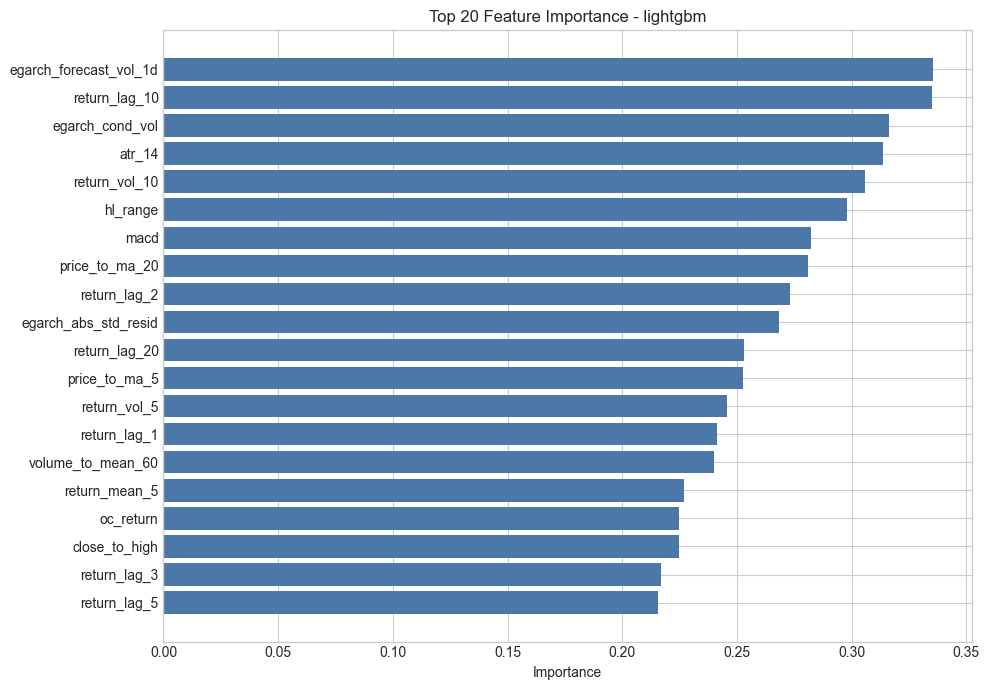

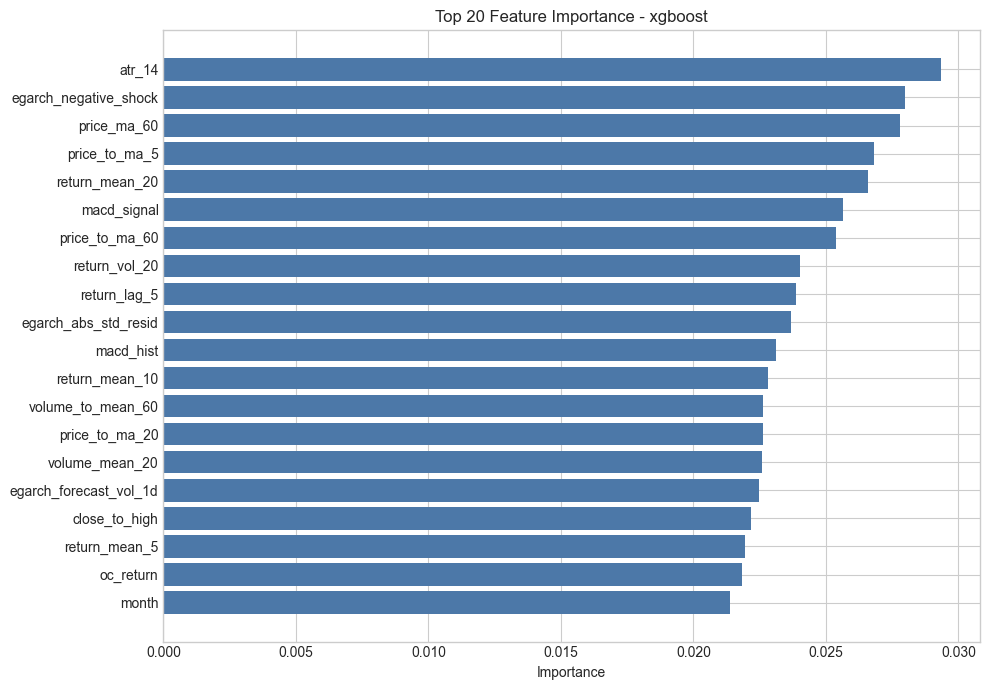

In [30]:
def plot_price_and_volume(data):
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
    axes[0].plot(data["date"], data["close"], color="#1f77b4", linewidth=1.4)
    axes[0].set_title("VIC Close Price")
    axes[0].set_ylabel("Close")
    axes[1].bar(data["date"], data["volume"], color="#9aa0a6", width=1.0)
    axes[1].set_title("Trading Volume")
    axes[1].set_ylabel("Volume")
    plt.tight_layout()
    plt.show()

def plot_returns_and_volatility(data):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
    axes[0].plot(data["date"], data["return_1d"], color="#444444", linewidth=0.8)
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_title("Daily Log Return")
    axes[0].set_ylabel("Return")

    axes[1].hist(data["return_1d"].dropna(), bins=80, color="#4c78a8", alpha=0.85)
    axes[1].set_title("Return Distribution")
    axes[1].set_xlabel("Daily log return")
    axes[1].set_ylabel("Frequency")

    axes[2].plot(data["date"], data["return_1d"].rolling(20).std(), label="Rolling vol 20D", color="#f58518")
    axes[2].plot(data["date"], data["return_1d"].rolling(60).std(), label="Rolling vol 60D", color="#54a24b")
    axes[2].set_title("Rolling Volatility")
    axes[2].set_ylabel("Volatility")
    axes[2].legend()
    plt.tight_layout()
    plt.show()

def plot_egarch_features(data):
    egarch_cols = [col for col in ["egarch_cond_vol", "egarch_forecast_vol_1d"] if col in data.columns and data[col].notna().any()]
    if not egarch_cols:
        print("Không có EGARCH features để vẽ. Kiểm tra package 'arch' hoặc CONFIG['use_egarch'].")
        return
    fig, ax = plt.subplots(figsize=(14, 5))
    for col in egarch_cols:
        ax.plot(data["date"], data[col], linewidth=1.2, label=col)
    ax.plot(data["date"], data["return_1d"].rolling(20).std(), color="#777777", alpha=0.6, label="rolling_vol_20")
    ax.set_title("EGARCH Volatility Features vs Rolling Volatility")
    ax.set_ylabel("Volatility")
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_predictions(pred_df):
    model_names = pred_df["model"].unique()
    fig, axes = plt.subplots(len(model_names), 2, figsize=(15, 4.5 * len(model_names)))
    if len(model_names) == 1:
        axes = np.array([axes])
    for row, model_name in enumerate(model_names):
        group = pred_df[pred_df["model"] == model_name].sort_values("date")
        axes[row, 0].plot(group["date"], group["actual_return"], label="Actual", color="#4c78a8", linewidth=1.0)
        axes[row, 0].plot(group["date"], group["predicted_return"], label="Predicted", color="#f58518", linewidth=1.0)
        axes[row, 0].axhline(0, color="black", linewidth=0.8)
        axes[row, 0].set_title(f"Actual vs Predicted Return - {model_name}")
        axes[row, 0].legend()

        axes[row, 1].scatter(group["actual_return"], group["predicted_return"], alpha=0.65, color="#54a24b")
        min_v = min(group["actual_return"].min(), group["predicted_return"].min())
        max_v = max(group["actual_return"].max(), group["predicted_return"].max())
        axes[row, 1].plot([min_v, max_v], [min_v, max_v], color="black", linewidth=0.8)
        axes[row, 1].set_title(f"Prediction Scatter - {model_name}")
        axes[row, 1].set_xlabel("Actual return")
        axes[row, 1].set_ylabel("Predicted return")
    plt.tight_layout()
    plt.show()

def plot_backtest_equity(pred_df):
    fig, ax = plt.subplots(figsize=(14, 6))
    for model_name, group in pred_df.groupby("model"):
        bt = backtest_long_flat(group, transaction_cost_bps=CONFIG["transaction_cost_bps"])
        ax.plot(bt["date"], bt["strategy_equity"], linewidth=1.5, label=f"{model_name} strategy")
    first_model = next(iter(pred_df["model"].unique()))
    bh = backtest_long_flat(pred_df[pred_df["model"] == first_model], transaction_cost_bps=CONFIG["transaction_cost_bps"])
    ax.plot(bh["date"], bh["buy_hold_equity"], color="black", linestyle="--", linewidth=1.2, label="Buy & hold")
    ax.set_title("Backtest Equity Curve")
    ax.set_ylabel("Equity, initial = 1.0")
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_feature_importance(models, feature_cols, top_n=20):
    for model_name, model in models.items():
        if hasattr(model, "feature_importance"):
            values = model.feature_importance(importance_type="gain")
        elif hasattr(model, "feature_importances_"):
            values = model.feature_importances_
        else:
            print(f"{model_name}: không có feature importance.")
            continue
        imp = pd.DataFrame({"feature": feature_cols, "importance": values}).sort_values("importance", ascending=False).head(top_n)
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.barh(imp["feature"][::-1], imp["importance"][::-1], color="#4c78a8")
        ax.set_title(f"Top {top_n} Feature Importance - {model_name}")
        ax.set_xlabel("Importance")
        plt.tight_layout()
        plt.show()

plot_price_and_volume(df)
plot_returns_and_volatility(df)
plot_egarch_features(df)
plot_predictions(predictions_df)
plot_backtest_equity(predictions_df)
plot_feature_importance(models, feature_cols, top_n=20)

## 13. Dashboard Diễn Giải Mô Hình

Phần này biến kết quả thành các biểu đồ dễ đưa vào báo cáo nghiên cứu hơn: chia train/validation/test trên chart giá, volatility regime, bảng so sánh model, lỗi dự báo, confusion matrix chiều tăng/giảm, vị thế giao dịch và drawdown.

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<p>Cell này tạo thư mục <code>reports/figures</code> và hàm lưu biểu đồ. Trong nghiên cứu khoa học, việc tự động lưu hình giúp bảo đảm reproducibility: hình trong báo cáo có thể truy vết trực tiếp về code, dữ liệu và cấu hình đã tạo ra nó.</p>

</div>

In [31]:
FIG_DIR = CONFIG["report_dir"] / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_current_fig(name):
    path = FIG_DIR / name
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved figure: {path}")

def metric_table(metrics, backtest_metrics):
    rows = []
    for model_name in metrics:
        row = {"model": model_name, **metrics[model_name], **backtest_metrics.get(model_name, {})}
        rows.append(row)
    table = pd.DataFrame(rows).set_index("model")
    display(table.style.format({
        "rmse": "{:.5f}",
        "mae": "{:.5f}",
        "r2": "{:.4f}",
        "directional_accuracy": "{:.2%}",
        "f1_direction": "{:.2%}",
        "strategy_total_return": "{:.2%}",
        "buy_hold_total_return": "{:.2%}",
        "strategy_sharpe": "{:.2f}",
        "strategy_max_drawdown": "{:.2%}",
    }))
    return table

summary_table = metric_table(metrics, backtest_metrics)
best_model = summary_table["rmse"].idxmin()
print("Best model by RMSE:", best_model)

,rmse,mae,r2,directional_accuracy,f1_direction,strategy_total_return,buy_hold_total_return,strategy_sharpe,strategy_max_drawdown
model,,,,,,,,,
lightgbm,0.03413,0.02582,-0.0786,52.25%,58.94%,358.98%,990.59%,2.68,-26.56%
xgboost,0.03685,0.02844,-0.2571,49.72%,44.24%,157.74%,990.59%,2.34,-18.08%


Best model by RMSE: lightgbm


<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<p>Việc tô vùng train/validation/test trên chart giá giúp người đọc hiểu mô hình học từ giai đoạn nào và được kiểm định ở giai đoạn nào. Volatility regime chia thị trường thành low/medium/high volatility, cho phép kiểm tra trực quan liệu mô hình có gặp khó trong giai đoạn biến động mạnh hay không.</p>

</div>

Saved figure: reports/figures/01_price_split.png


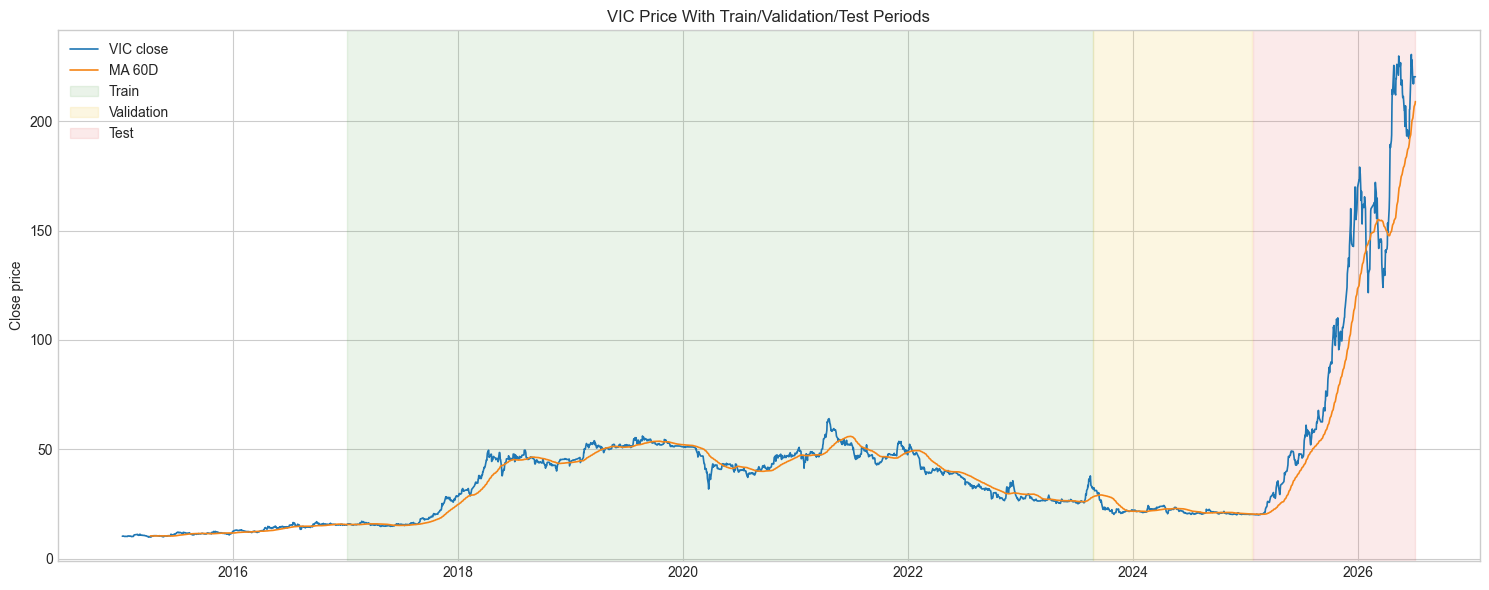

Saved figure: reports/figures/02_volatility_regime.png


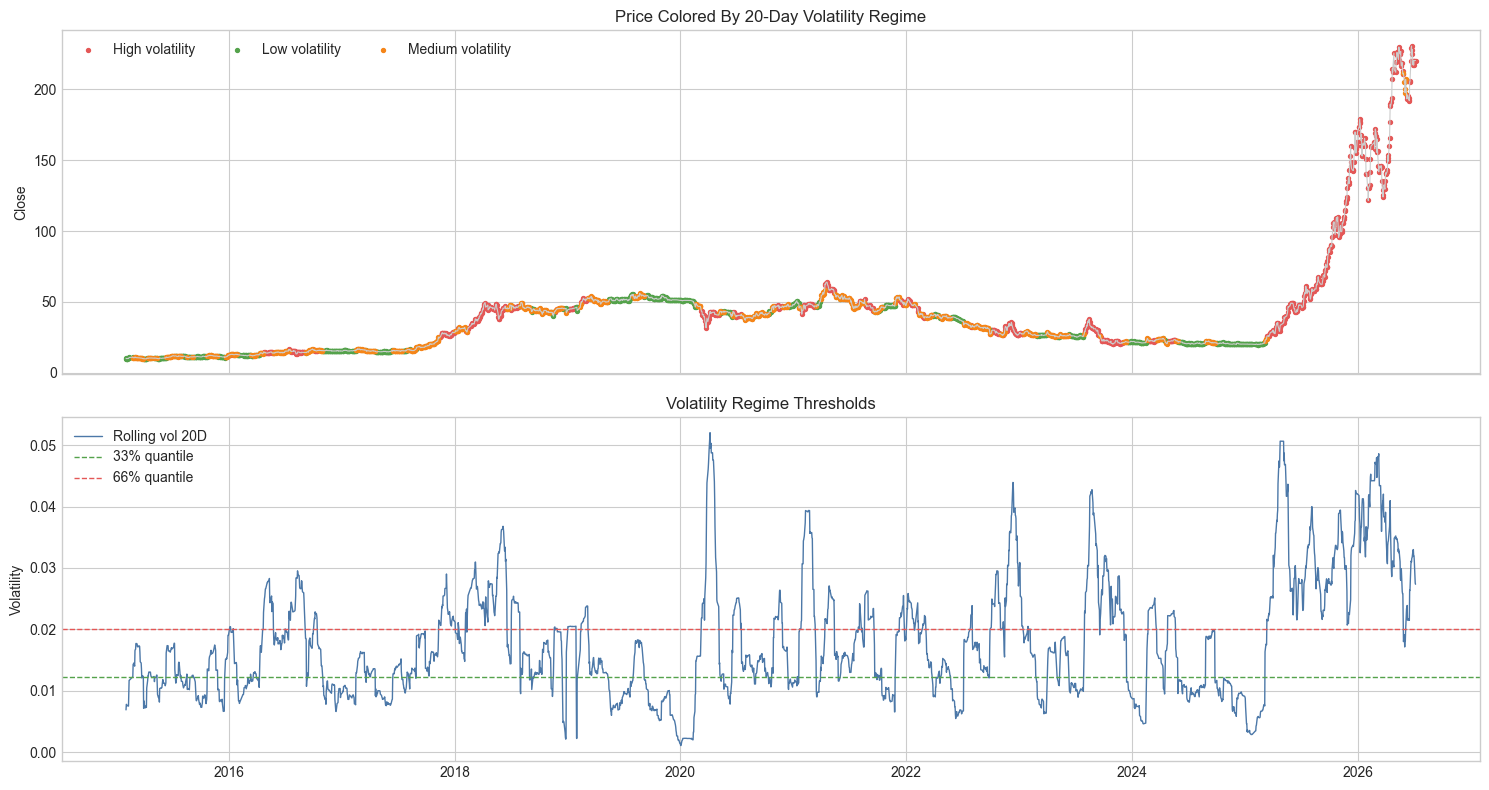

In [32]:
def plot_data_split_story(data, train_df, valid_df, test_df):
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(data["date"], data["close"], color="#1f77b4", linewidth=1.2, label="VIC close")
    ax.plot(data["date"], data["close"].rolling(60).mean(), color="#f58518", linewidth=1.2, label="MA 60D")
    ax.axvspan(train_df["date"].min(), train_df["date"].max(), color="#54a24b", alpha=0.12, label="Train")
    ax.axvspan(valid_df["date"].min(), valid_df["date"].max(), color="#f2cf5b", alpha=0.18, label="Validation")
    ax.axvspan(test_df["date"].min(), test_df["date"].max(), color="#e45756", alpha=0.12, label="Test")
    ax.set_title("VIC Price With Train/Validation/Test Periods")
    ax.set_ylabel("Close price")
    ax.legend(loc="upper left")
    plt.tight_layout()
    save_current_fig("01_price_split.png")
    plt.show()

def plot_volatility_regime(data):
    tmp = data[["date", "close", "return_1d"]].copy()
    tmp["vol_20"] = tmp["return_1d"].rolling(20).std()
    tmp = tmp.dropna(subset=["vol_20"])
    q_low, q_high = tmp["vol_20"].quantile([0.33, 0.66])
    tmp["regime"] = np.select(
        [tmp["vol_20"] <= q_low, tmp["vol_20"] >= q_high],
        ["Low volatility", "High volatility"],
        default="Medium volatility",
    )
    colors = {"Low volatility": "#54a24b", "Medium volatility": "#f58518", "High volatility": "#e45756"}

    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    axes[0].plot(tmp["date"], tmp["close"], color="#cccccc", linewidth=0.8)
    for regime, group in tmp.groupby("regime"):
        axes[0].scatter(group["date"], group["close"], s=8, color=colors[regime], label=regime)
    axes[0].set_title("Price Colored By 20-Day Volatility Regime")
    axes[0].set_ylabel("Close")
    axes[0].legend(ncol=3)

    axes[1].plot(tmp["date"], tmp["vol_20"], color="#4c78a8", linewidth=1.0, label="Rolling vol 20D")
    axes[1].axhline(q_low, color="#54a24b", linestyle="--", linewidth=1.0, label="33% quantile")
    axes[1].axhline(q_high, color="#e45756", linestyle="--", linewidth=1.0, label="66% quantile")
    axes[1].set_title("Volatility Regime Thresholds")
    axes[1].set_ylabel("Volatility")
    axes[1].legend()
    plt.tight_layout()
    save_current_fig("02_volatility_regime.png")
    plt.show()

plot_data_split_story(df, train_df, valid_df, test_df)
plot_volatility_regime(df)

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<h4 style="margin-top:0">Phân tích lỗi dự báo</h4>
<p>Không chỉ xem sai số trung bình, cell này phân rã lỗi dự báo thành residual distribution, rolling directional accuracy và confusion matrix. Cách nhìn này cho biết mô hình sai do lệch mức return, do không bắt được chiều tăng/giảm, hay do hiệu quả suy giảm theo thời gian.</p>

</div>

Saved figure: reports/figures/03_error_dashboard_lightgbm.png


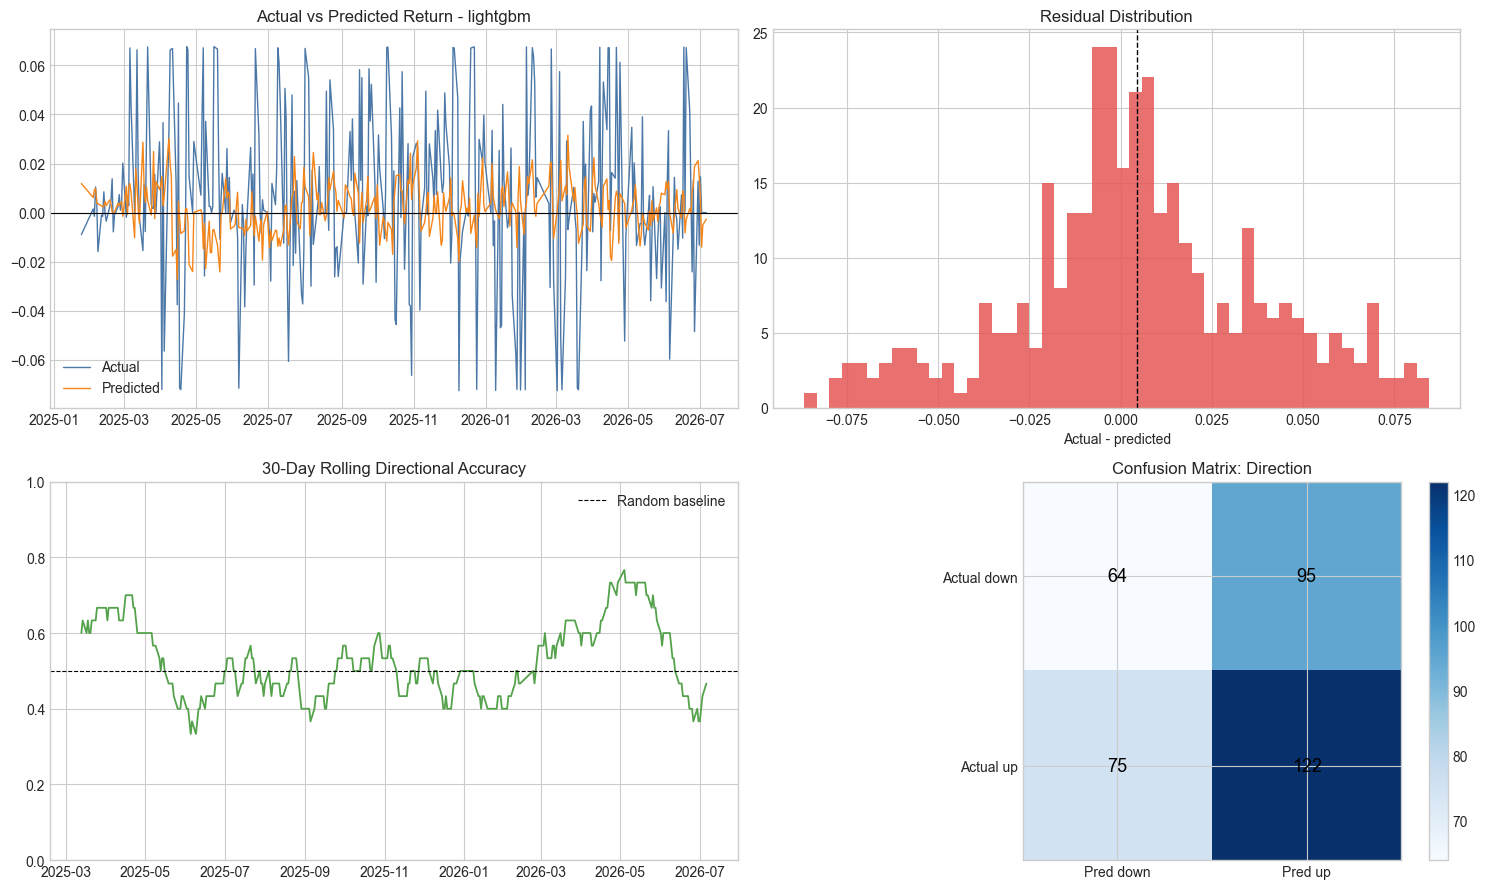

Saved figure: reports/figures/03_error_dashboard_xgboost.png


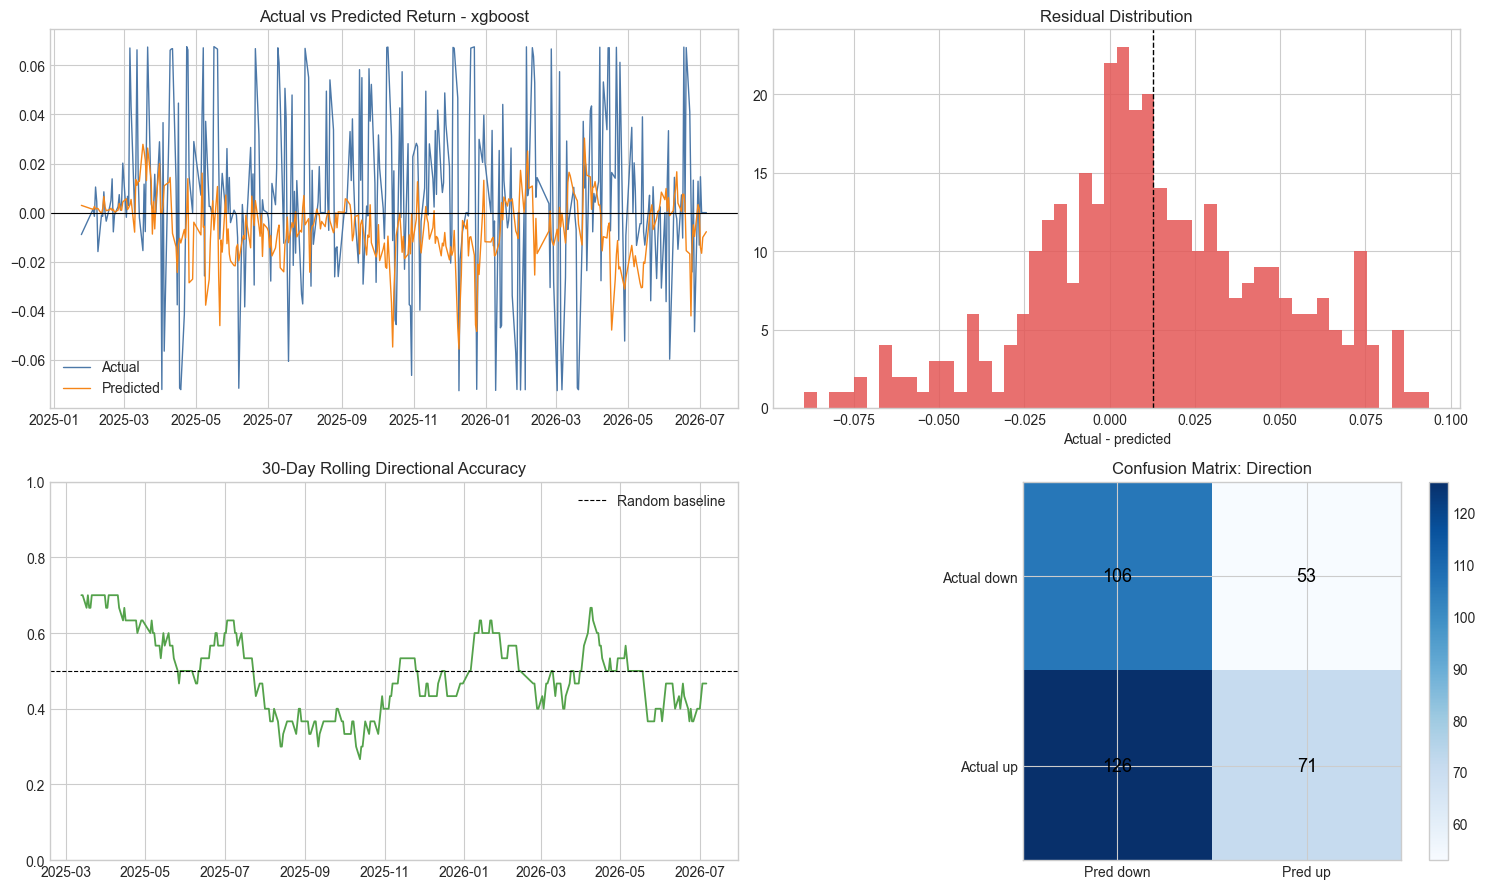

In [33]:
def confusion_counts(actual_direction, predicted_direction):
    actual_direction = np.asarray(actual_direction).astype(int)
    predicted_direction = np.asarray(predicted_direction).astype(int)
    tn = int(np.sum((actual_direction == 0) & (predicted_direction == 0)))
    fp = int(np.sum((actual_direction == 0) & (predicted_direction == 1)))
    fn = int(np.sum((actual_direction == 1) & (predicted_direction == 0)))
    tp = int(np.sum((actual_direction == 1) & (predicted_direction == 1)))
    return np.array([[tn, fp], [fn, tp]])

def plot_model_error_dashboard(pred_df, model_name):
    group = pred_df[pred_df["model"] == model_name].sort_values("date").copy()
    group["residual"] = group["actual_return"] - group["predicted_return"]
    group["rolling_directional_accuracy"] = (
        (group["actual_direction"] == group["predicted_direction"]).rolling(30).mean()
    )
    cm = confusion_counts(group["actual_direction"], group["predicted_direction"])

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    axes[0, 0].plot(group["date"], group["actual_return"], color="#4c78a8", label="Actual", linewidth=1.0)
    axes[0, 0].plot(group["date"], group["predicted_return"], color="#f58518", label="Predicted", linewidth=1.0)
    axes[0, 0].axhline(0, color="black", linewidth=0.8)
    axes[0, 0].set_title(f"Actual vs Predicted Return - {model_name}")
    axes[0, 0].legend()

    axes[0, 1].hist(group["residual"], bins=50, color="#e45756", alpha=0.85)
    axes[0, 1].axvline(group["residual"].mean(), color="black", linestyle="--", linewidth=1.0)
    axes[0, 1].set_title("Residual Distribution")
    axes[0, 1].set_xlabel("Actual - predicted")

    axes[1, 0].plot(group["date"], group["rolling_directional_accuracy"], color="#54a24b", linewidth=1.3)
    axes[1, 0].axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="Random baseline")
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].set_title("30-Day Rolling Directional Accuracy")
    axes[1, 0].legend()

    im = axes[1, 1].imshow(cm, cmap="Blues")
    axes[1, 1].set_title("Confusion Matrix: Direction")
    axes[1, 1].set_xticks([0, 1], labels=["Pred down", "Pred up"])
    axes[1, 1].set_yticks([0, 1], labels=["Actual down", "Actual up"])
    for i in range(2):
        for j in range(2):
            axes[1, 1].text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=13)
    fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    save_current_fig(f"03_error_dashboard_{model_name}.png")
    plt.show()

for model_name in predictions_df["model"].unique():
    plot_model_error_dashboard(predictions_df, model_name)

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<h4 style="margin-top:0">Diễn giải tín hiệu giao dịch</h4>
<p>Chart tín hiệu long trên giá giúp kiểm tra mô hình có mua ở các vùng hợp lý hay không. Equity curve và drawdown cho thấy chiến lược có tạo lợi nhuận đều hay chỉ nhờ một vài giai đoạn may mắn. Đây là phần cần thiết khi chuyển từ dự báo thống kê sang giá trị đầu tư.</p>

</div>

Saved figure: reports/figures/04_strategy_dashboard_lightgbm.png


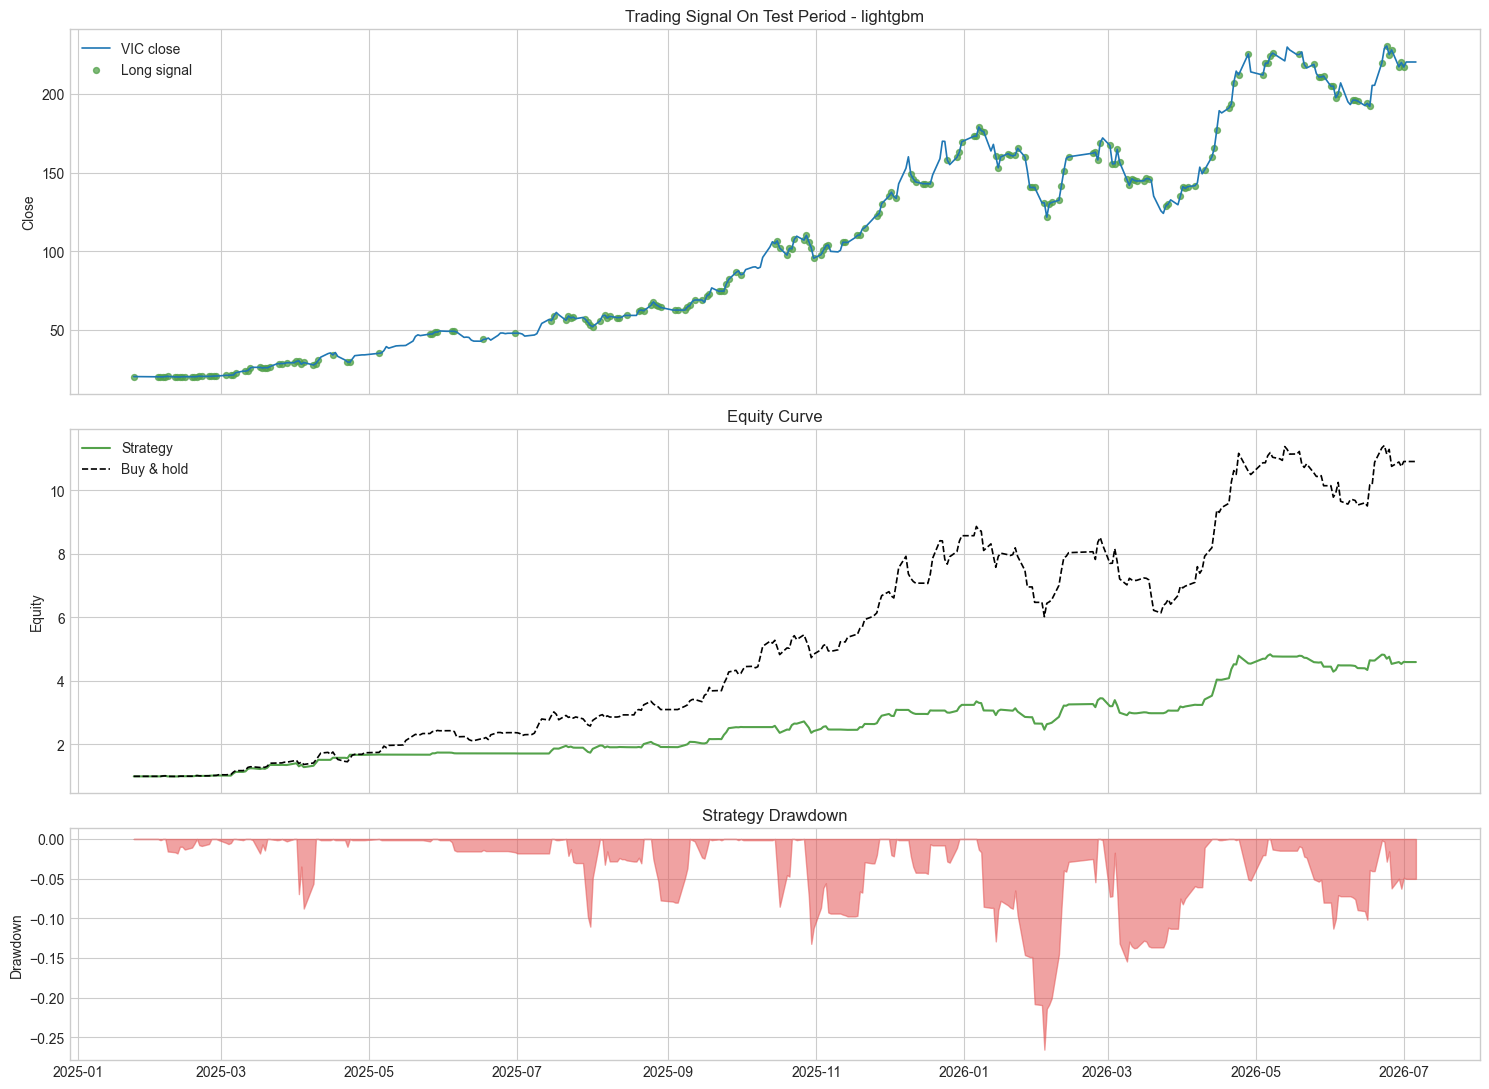

In [34]:
def plot_strategy_dashboard(pred_df, model_name):
    group = pred_df[pred_df["model"] == model_name].sort_values("date")
    bt = backtest_long_flat(group, transaction_cost_bps=CONFIG["transaction_cost_bps"])
    test_prices = df[["date", "close"]].merge(bt[["date", "position", "strategy_equity", "buy_hold_equity"]], on="date", how="inner")
    drawdown = bt["strategy_equity"] / bt["strategy_equity"].cummax() - 1

    fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True, gridspec_kw={"height_ratios": [2.2, 2.2, 1.4]})
    axes[0].plot(test_prices["date"], test_prices["close"], color="#1f77b4", linewidth=1.2, label="VIC close")
    buy_dates = test_prices.loc[test_prices["position"] == 1, "date"]
    buy_prices = test_prices.loc[test_prices["position"] == 1, "close"]
    axes[0].scatter(buy_dates, buy_prices, color="#54a24b", s=18, label="Long signal", alpha=0.75)
    axes[0].set_title(f"Trading Signal On Test Period - {model_name}")
    axes[0].set_ylabel("Close")
    axes[0].legend()

    axes[1].plot(bt["date"], bt["strategy_equity"], color="#54a24b", linewidth=1.5, label="Strategy")
    axes[1].plot(bt["date"], bt["buy_hold_equity"], color="black", linestyle="--", linewidth=1.2, label="Buy & hold")
    axes[1].set_title("Equity Curve")
    axes[1].set_ylabel("Equity")
    axes[1].legend()

    axes[2].fill_between(bt["date"], drawdown, 0, color="#e45756", alpha=0.55)
    axes[2].set_title("Strategy Drawdown")
    axes[2].set_ylabel("Drawdown")
    plt.tight_layout()
    save_current_fig(f"04_strategy_dashboard_{model_name}.png")
    plt.show()

plot_strategy_dashboard(predictions_df, best_model)

<div style="border-left:4px solid #2f6fbb; background:#f6f9ff; padding:12px 16px; margin:10px 0; border-radius:6px;">
<h4 style="margin-top:0">Gom nhóm feature importance</h4>
<p>Thay vì chỉ liệt kê từng biến, cell này gom feature thành nhóm nghiên cứu: EGARCH volatility, return memory, volatility/range, volume, technical trend và calendar. Cách gom nhóm giúp trả lời câu hỏi học thuật rõ hơn: nguồn thông tin nào đóng góp nhiều nhất vào mô hình lai?</p>

</div>

Saved figure: reports/figures/05_feature_group_importance.png


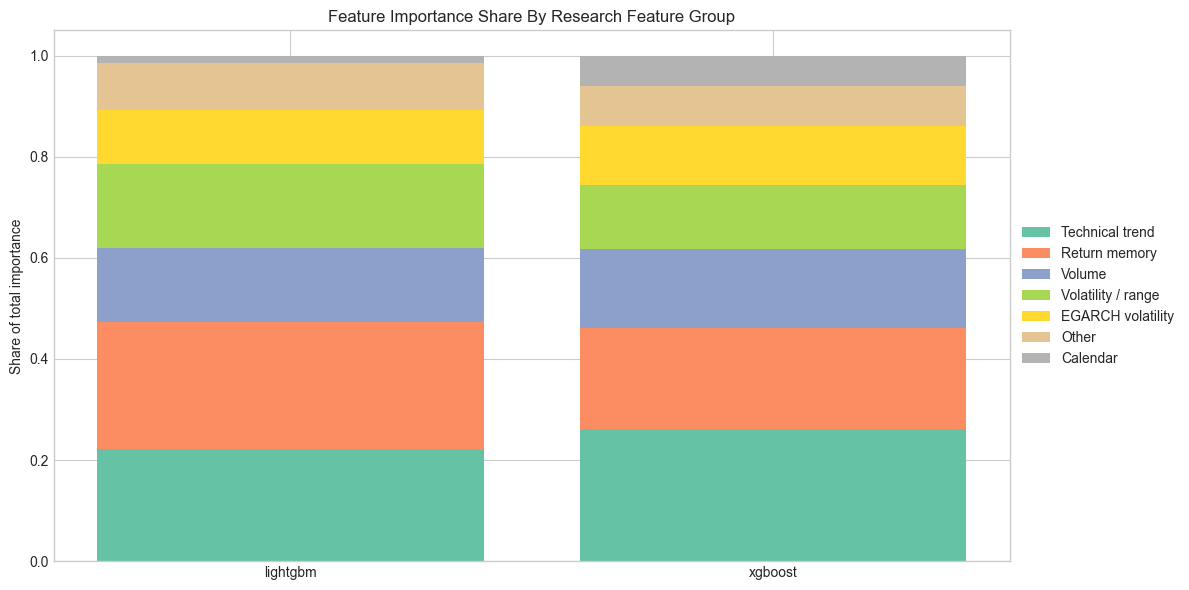

,model,group,importance,share
3,lightgbm,Return memory,2.357442,0.252090
4,lightgbm,Technical trend,2.069880,0.221340
5,lightgbm,Volatility / range,1.548928,0.165632
6,lightgbm,Volume,1.371446,0.146654
1,lightgbm,EGARCH volatility,1.003878,0.107348
2,lightgbm,Other,0.857275,0.091671
0,lightgbm,Calendar,0.142756,0.015265
11,xgboost,Technical trend,0.261095,0.261095
10,xgboost,Return memory,0.200498,0.200498
13,xgboost,Volume,0.155603,0.155603


In [35]:
def feature_group(feature):
    if feature.startswith("egarch"):
        return "EGARCH volatility"
    if feature.startswith("return_lag") or feature.startswith("return_mean"):
        return "Return memory"
    if feature.startswith("return_vol") or feature in ["hl_range", "atr_14"]:
        return "Volatility / range"
    if feature.startswith("volume"):
        return "Volume"
    if feature.startswith("price") or feature in ["macd", "macd_signal", "macd_hist", "rsi_14"]:
        return "Technical trend"
    if feature in ["day_of_week", "month", "is_month_end"]:
        return "Calendar"
    return "Other"

def plot_feature_group_importance(models, feature_cols):
    rows = []
    for model_name, model in models.items():
        if hasattr(model, "feature_importance"):
            values = model.feature_importance(importance_type="gain")
        elif hasattr(model, "feature_importances_"):
            values = model.feature_importances_
        else:
            continue
        tmp = pd.DataFrame({"model": model_name, "feature": feature_cols, "importance": values})
        tmp["group"] = tmp["feature"].map(feature_group)
        rows.append(tmp)
    if not rows:
        print("Không có feature importance để gom nhóm.")
        return
    imp = pd.concat(rows, ignore_index=True)
    grouped = imp.groupby(["model", "group"], as_index=False)["importance"].sum()
    grouped["share"] = grouped["importance"] / grouped.groupby("model")["importance"].transform("sum")

    models_order = grouped["model"].unique()
    groups_order = grouped.groupby("group")["share"].mean().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(12, 6))
    bottom = np.zeros(len(models_order))
    color_map = plt.cm.Set2(np.linspace(0, 1, len(groups_order)))
    for color, group_name in zip(color_map, groups_order):
        values = []
        for model_name in models_order:
            value = grouped[(grouped["model"] == model_name) & (grouped["group"] == group_name)]["share"]
            values.append(float(value.iloc[0]) if len(value) else 0.0)
        ax.bar(models_order, values, bottom=bottom, label=group_name, color=color)
        bottom += np.array(values)
    ax.set_title("Feature Importance Share By Research Feature Group")
    ax.set_ylabel("Share of total importance")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    save_current_fig("05_feature_group_importance.png")
    plt.show()
    display(grouped.sort_values(["model", "share"], ascending=[True, False]))

plot_feature_group_importance(models, feature_cols)